# Quicksort Pairwise Swap Trace

Run the benchmark with tracing enabled, for example:

```bash
./build-local-release/benchmark_quicksort_pairwise_swap \
  --trials 30 \
  --output build-local-release/benchmark_quicksort_pairwise_swap_32bit.tsv \
  --trace-output build-local-release/benchmark_quicksort_pairwise_swap_trace.tsv
```

Tracing is opt-in and adds timer/counter overhead. Use this notebook to locate where time goes inside `tsl_pairwise_swap`; use the normal benchmark TSV for headline performance numbers.

In [ ]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

pd.set_option('display.max_columns', 120)

def format_bytes(value, _position=None):
    value = float(value)
    for suffix in ['B', 'KiB', 'MiB', 'GiB']:
        if value < 1024 or suffix == 'GiB':
            return f'{value:g}{suffix}'
        value /= 1024

candidates = [
    Path('build-local-release/benchmark_quicksort_pairwise_swap_trace.tsv'),
    Path('build-local-release/benchmark_quicksort_pairwise_swap_32bit_trace.tsv'),
    # Path('build-local-release/quicksort_pairwise_swap_trace.tsv'),
    # Path('build-local/quicksort_pairwise_swap_trace.tsv'),
    # Path('test-sort/build-local-release/benchmark_quicksort_pairwise_swap_trace.tsv'),
    # Path('test-sort/build-local-release/benchmark_quicksort_pairwise_swap_32bit_trace.tsv'),
    # Path('test-sort/build-local-release/quicksort_pairwise_swap_trace.tsv'),
    # Path('test-sort/build-local/quicksort_pairwise_swap_trace.tsv'),
    # Path('tslctmp/quicksort_pairwise_trace.tsv'),
    # Path('tslctmp/quicksort_pairwise_trace_4k.tsv'),
    # Path('../tslctmp/quicksort_pairwise_trace.tsv'),
    # Path('../tslctmp/quicksort_pairwise_trace_4k.tsv'),
]
trace_path = next((path for path in candidates if path.exists()), candidates[0])
print(f'Loading {trace_path}')

df = pd.read_csv(trace_path, sep='\t')
histogram_columns = [column for column in df.columns if column.endswith('_histogram')]
text_columns = {'algorithm', 'distribution', 'size_label', *histogram_columns}
for column in df.columns:
    if column not in text_columns:
        df[column] = pd.to_numeric(df[column], errors='coerce')

required_columns = {
    'distribution', 'size', 'bytes', 'size_label', 'elapsed_ns',
    'leaf_sort_ns', 'pivot_ns', 'less_elapsed_ns', 'equal_elapsed_ns',
    'less_input_elements', 'equal_input_elements',
}
missing_columns = sorted(required_columns - set(df.columns))
if missing_columns:
    raise ValueError(f'Trace TSV is missing expected columns: {missing_columns}')

df.head()

Loading build-local-release/benchmark_quicksort_pairwise_swap_trace.tsv


,algorithm,distribution,size,bytes,size_label,trial,input_seed,sort_seed,elapsed_ns,checksum,simd_lanes,sort_calls,trivial_calls,max_depth,max_sort_elements,leaf_sort_calls,leaf_sort_elements,leaf_sort_ns,pivot_calls,pivot_elements,pivot_ns,less_calls,less_input_elements,less_elapsed_ns,less_vectorized_calls,less_vector_iterations,less_left_loads,less_right_loads,less_left_all_good,less_right_all_good,less_swap_iterations,less_swappable_lanes,less_good_left_lanes,less_good_right_lanes,less_carry_left_lanes,less_carry_right_lanes,less_left_progress_elements,less_right_progress_elements,less_scalar_span_elements,less_scalar_left_steps,less_scalar_right_steps,less_scalar_swaps,less_left_bad_lane_histogram,less_right_bad_lane_histogram,equal_calls,equal_input_elements,equal_elapsed_ns,equal_vectorized_calls,equal_vector_iterations,equal_left_loads,equal_right_loads,equal_left_all_good,equal_right_all_good,equal_swap_iterations,equal_swappable_lanes,equal_good_left_lanes,equal_good_right_lanes,equal_carry_left_lanes,equal_carry_right_lanes,equal_left_progress_elements,equal_right_progress_elements,equal_scalar_span_elements,equal_scalar_left_steps,equal_scalar_right_steps,equal_scalar_swaps,equal_left_bad_lane_histogram,equal_right_bad_lane_histogram
0,tsl_pairwise_swap,uniform_random,256,1024,1KiB,0,3700666610937382492,12072779612692895671,5308,5871538558057581094,16,1,0,0,256,1,256,5143,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,empty,empty,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,empty,empty
1,tsl_pairwise_swap,uniform_random,256,1024,1KiB,1,10449163019489165923,419586678491829128,4045,6135093614127063641,16,1,0,0,256,1,256,3995,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,empty,empty,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,empty,empty
2,tsl_pairwise_swap,uniform_random,256,1024,1KiB,2,8631848224283905654,16364451032370405277,3757,17236362272671727389,16,1,0,0,256,1,256,3723,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,empty,empty,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,empty,empty
3,tsl_pairwise_swap,uniform_random,256,1024,1KiB,3,15398361213191703069,4711255916287155190,3670,7567582054125982107,16,1,0,0,256,1,256,3629,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,empty,empty,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,empty,empty
4,tsl_pairwise_swap,uniform_random,256,1024,1KiB,4,13436895804953220640,3362280383824349131,3639,17122393071194906249,16,1,0,0,256,1,256,3606,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,empty,empty,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,empty,empty


In [16]:
phase_columns = {
    'leaf_sort_ns': 'leaf sort',
    'pivot_ns': 'pivot',
    'less_elapsed_ns': '< pivot partition',
    'equal_elapsed_ns': '== pivot partition',
}

df['measured_phase_ns'] = df[list(phase_columns)].sum(axis=1)
df['other_ns'] = (df['elapsed_ns'] - df['measured_phase_ns']).clip(lower=0)
df['timer_excess_ns'] = (df['measured_phase_ns'] - df['elapsed_ns']).clip(lower=0)
df['partition_ns'] = df['less_elapsed_ns'] + df['equal_elapsed_ns']
df['less_input_per_element'] = df['less_input_elements'] / df['size']
df['equal_input_per_element'] = df['equal_input_elements'] / df['size']
df['partition_input_per_element'] = (df['less_input_elements'] + df['equal_input_elements']) / df['size']
df['scalar_span_per_element'] = (df['less_scalar_span_elements'] + df['equal_scalar_span_elements']) / df['size']
df['vector_lanes_per_element'] = (
    (df['less_vector_iterations'] + df['equal_vector_iterations']) * df['simd_lanes'] / df['size']
)
swap_iterations = df['less_swap_iterations'] + df['equal_swap_iterations']
df['avg_swappable_lanes'] = (
    (df['less_swappable_lanes'] + df['equal_swappable_lanes'])
    / swap_iterations.where(swap_iterations != 0)
)

group_columns = ['distribution', 'size', 'bytes', 'size_label']
numeric_columns = [
    column for column in df.select_dtypes(include='number').columns
    if column not in {'trial', 'input_seed', 'sort_seed', 'checksum'}
]
summary = df.groupby(group_columns, as_index=False)[numeric_columns].median()
trial_counts = df.groupby(group_columns, as_index=False).agg(trials=('trial', 'nunique'))
summary = summary.merge(trial_counts, on=group_columns)
summary['ns_per_element'] = summary['elapsed_ns'] / summary['size']
summary.sort_values(['distribution', 'bytes']).head()

,distribution,size_label,size,bytes,elapsed_ns,simd_lanes,sort_calls,trivial_calls,max_depth,max_sort_elements,leaf_sort_calls,leaf_sort_elements,leaf_sort_ns,pivot_calls,pivot_elements,pivot_ns,less_calls,less_input_elements,less_elapsed_ns,less_vectorized_calls,less_vector_iterations,less_left_loads,less_right_loads,less_left_all_good,less_right_all_good,less_swap_iterations,less_swappable_lanes,less_good_left_lanes,less_good_right_lanes,less_carry_left_lanes,less_carry_right_lanes,less_left_progress_elements,less_right_progress_elements,less_scalar_span_elements,less_scalar_left_steps,less_scalar_right_steps,less_scalar_swaps,equal_calls,equal_input_elements,equal_elapsed_ns,equal_vectorized_calls,equal_vector_iterations,equal_left_loads,equal_right_loads,equal_left_all_good,equal_right_all_good,equal_swap_iterations,equal_swappable_lanes,equal_good_left_lanes,equal_good_right_lanes,equal_carry_left_lanes,equal_carry_right_lanes,equal_left_progress_elements,equal_right_progress_elements,equal_scalar_span_elements,equal_scalar_left_steps,equal_scalar_right_steps,equal_scalar_swaps,measured_phase_ns,other_ns,timer_excess_ns,partition_ns,less_input_per_element,equal_input_per_element,partition_input_per_element,scalar_span_per_element,vector_lanes_per_element,avg_swappable_lanes,trials,ns_per_element
0,ascending,1KiB,256.0,1024.0,3522.0,16.0,1.0,0.0,0.0,256.0,1.0,256.0,3489.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3489.5,32.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,30,13.757812
1,ascending,4KiB,1024.0,4096.0,28160.0,16.0,13.0,0.0,4.0,1024.0,7.0,1018.0,25473.5,6.0,3080.0,458.0,6.0,3080.0,961.5,6.0,183.0,98.0,92.5,92.0,92.5,0.0,0.0,0.0,0.0,0.0,0.0,1472.0,1480.0,149.5,42.0,106.5,0.0,6.0,1593.0,660.5,6.0,90.0,6.0,90.0,0.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1440.0,138.5,0.0,138.5,0.0,27469.5,671.5,0.0,1597.0,3.007812,1.555664,4.524902,0.279297,4.226562,NaN,30,27.500000
2,ascending,16KiB,4096.0,16384.0,111618.5,16.0,53.0,0.0,8.0,4096.0,27.0,4070.0,101017.0,26.0,21771.5,1170.5,26.0,21771.5,4767.5,26.0,1321.0,695.0,642.0,668.0,642.0,0.0,0.0,0.0,0.0,0.0,0.0,10688.0,10272.0,609.5,197.5,424.5,0.0,26.0,10714.0,2693.0,26.0,630.0,26.0,630.0,0.0,630.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10080.0,614.0,0.0,614.0,0.0,109368.0,2206.0,0.0,7523.0,5.315308,2.615723,7.934082,0.299438,7.626953,NaN,30,27.250610
3,ascending,64KiB,16384.0,65536.0,431537.0,16.0,219.0,0.0,12.0,16384.0,110.0,16275.0,385122.5,109.0,128911.5,4151.0,109.0,128911.5,21318.5,109.0,7884.0,3981.5,3767.5,3874.0,3767.5,0.0,0.0,0.0,0.0,0.0,0.0,61984.0,60280.0,2544.0,805.5,1736.0,0.0,109.0,62283.5,13020.0,107.0,3715.5,107.0,3715.5,0.0,3715.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,59448.0,2563.0,0.0,2563.0,0.0,423343.0,8228.5,0.0,34448.0,7.868134,3.801483,11.717010,0.311584,11.380859,NaN,30,26.338928
4,ascending,256KiB,65536.0,262144.0,1723176.0,16.0,875.0,0.0,16.0,65536.0,438.0,65099.0,1506280.0,437.0,677433.0,15763.0,437.0,677433.0,106842.0,437.0,41674.0,21599.5,20488.0,21168.5,20488.0,0.0,0.0,0.0,0.0,0.0,0.0,338696.0,327808.0,10270.0,3274.5,6948.0,0.0,437.0,335190.5,59828.5,430.5,20286.0,430.5,20286.0,0.0,20286.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,324576.0,10276.0,0.0,10276.0,0.0,1691296.5,32176.5,0.0,166511.5,10.336807,5.114601,15.514816,0.314064,15.194702,NaN,30,26.293579


## Phase Share

These shares use the trace timers inside the sorter. They are approximate because the timers themselves are part of the traced run.

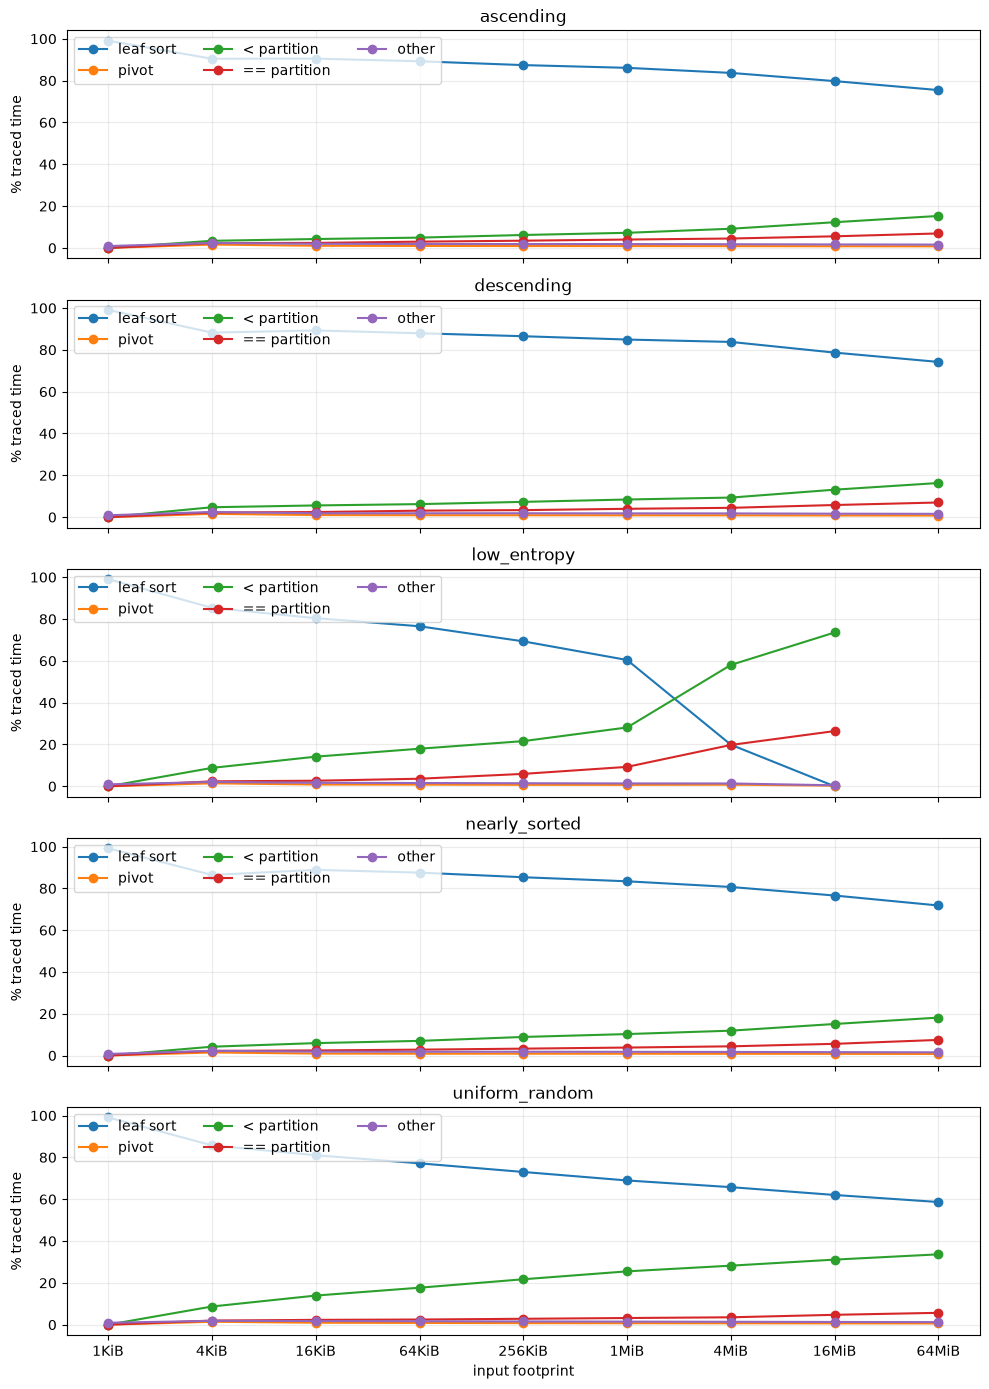

In [17]:
plot_phases = [
    ('leaf_sort_ns', 'leaf sort'),
    ('pivot_ns', 'pivot'),
    ('less_elapsed_ns', '< partition'),
    ('equal_elapsed_ns', '== partition'),
    ('other_ns', 'other'),
]

distributions = list(summary['distribution'].drop_duplicates())
fig, axes = plt.subplots(len(distributions), 1, figsize=(10, 2.8 * len(distributions)), sharex=True)
if len(distributions) == 1:
    axes = [axes]

for axis, distribution in zip(axes, distributions):
    group = summary[summary['distribution'] == distribution].sort_values('bytes')
    total = group['elapsed_ns'].where(group['elapsed_ns'] != 0)
    for column, label in plot_phases:
        axis.plot(group['bytes'], 100.0 * group[column] / total, marker='o', label=label)
    axis.set_xscale('log', base=2)
    axis.xaxis.set_major_formatter(mticker.FuncFormatter(format_bytes))
    axis.set_ylabel('% traced time')
    axis.set_title(distribution)
    axis.grid(True, which='both', axis='both', alpha=0.25)
    axis.legend(loc='upper left', ncols=3)

axes[-1].set_xlabel('input footprint')
fig.tight_layout()

## Partition Pressure

Input-elements-per-element is a useful way to see how much repeated scanning each partition pass causes. Values above 1 are expected over recursive calls; differences between `< pivot` and `== pivot` show the cost of the three-way cleanup pass.

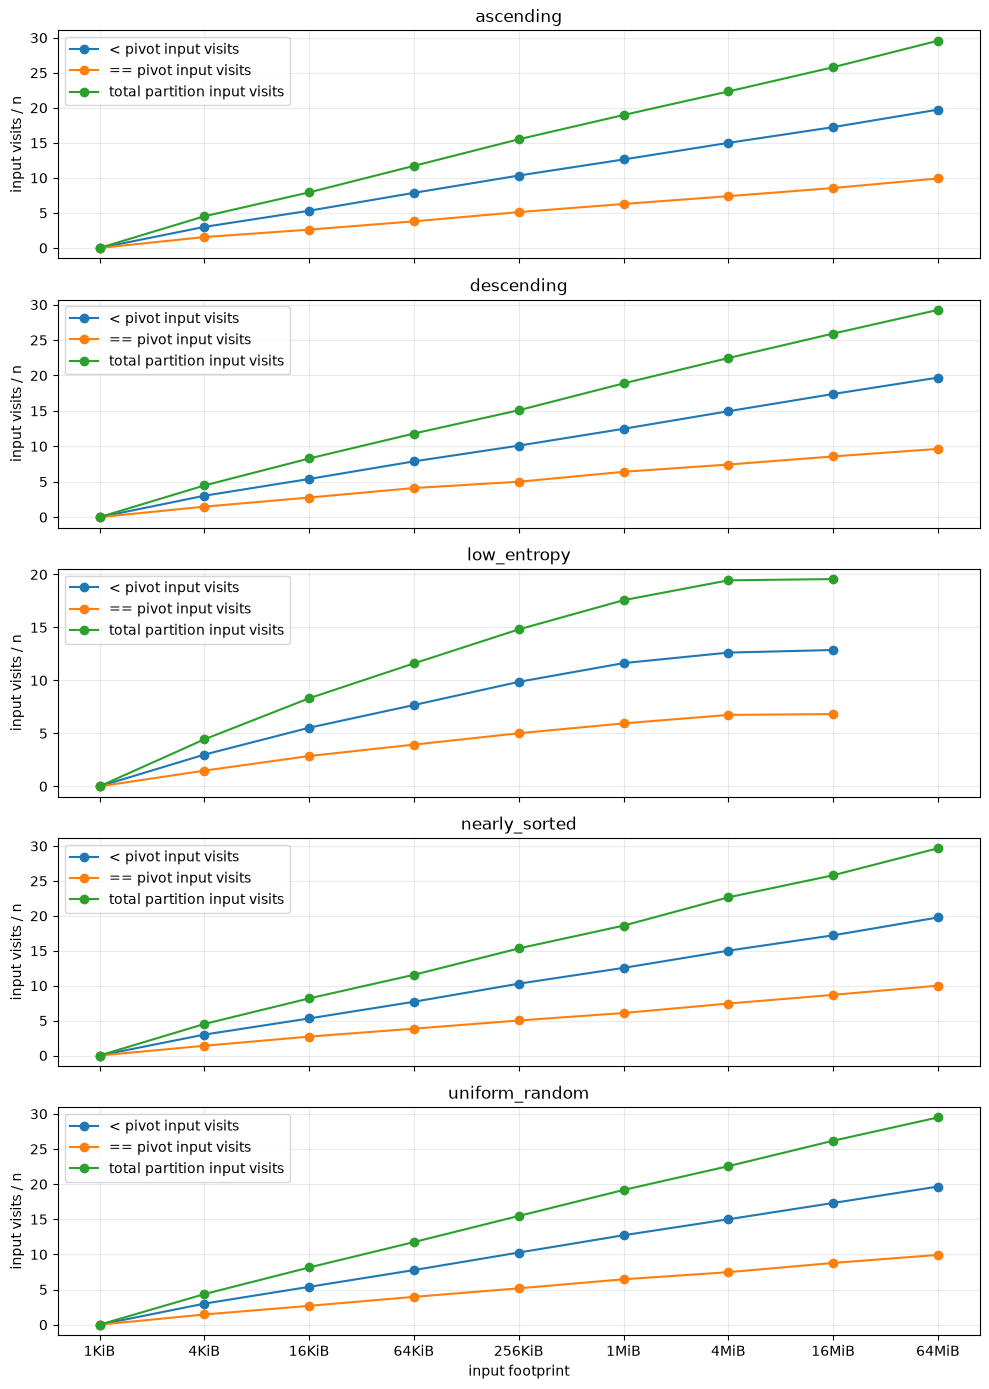

In [18]:
fig, axes = plt.subplots(len(distributions), 1, figsize=(10, 2.8 * len(distributions)), sharex=True)
if len(distributions) == 1:
    axes = [axes]

for axis, distribution in zip(axes, distributions):
    group = summary[summary['distribution'] == distribution].sort_values('bytes')
    axis.plot(group['bytes'], group['less_input_per_element'], marker='o', label='< pivot input visits')
    axis.plot(group['bytes'], group['equal_input_per_element'], marker='o', label='== pivot input visits')
    axis.plot(group['bytes'], group['partition_input_per_element'], marker='o', label='total partition input visits')
    axis.set_xscale('log', base=2)
    axis.xaxis.set_major_formatter(mticker.FuncFormatter(format_bytes))
    axis.set_ylabel('input visits / n')
    axis.set_title(distribution)
    axis.grid(True, which='both', axis='both', alpha=0.25)
    axis.legend()

axes[-1].set_xlabel('input footprint')
fig.tight_layout()

## Vector And Scalar Work

`vector_lanes_per_element` estimates SIMD-lane traffic from vector loop iterations. `scalar_span_per_element` shows how much tail work survived the vector partition loop.

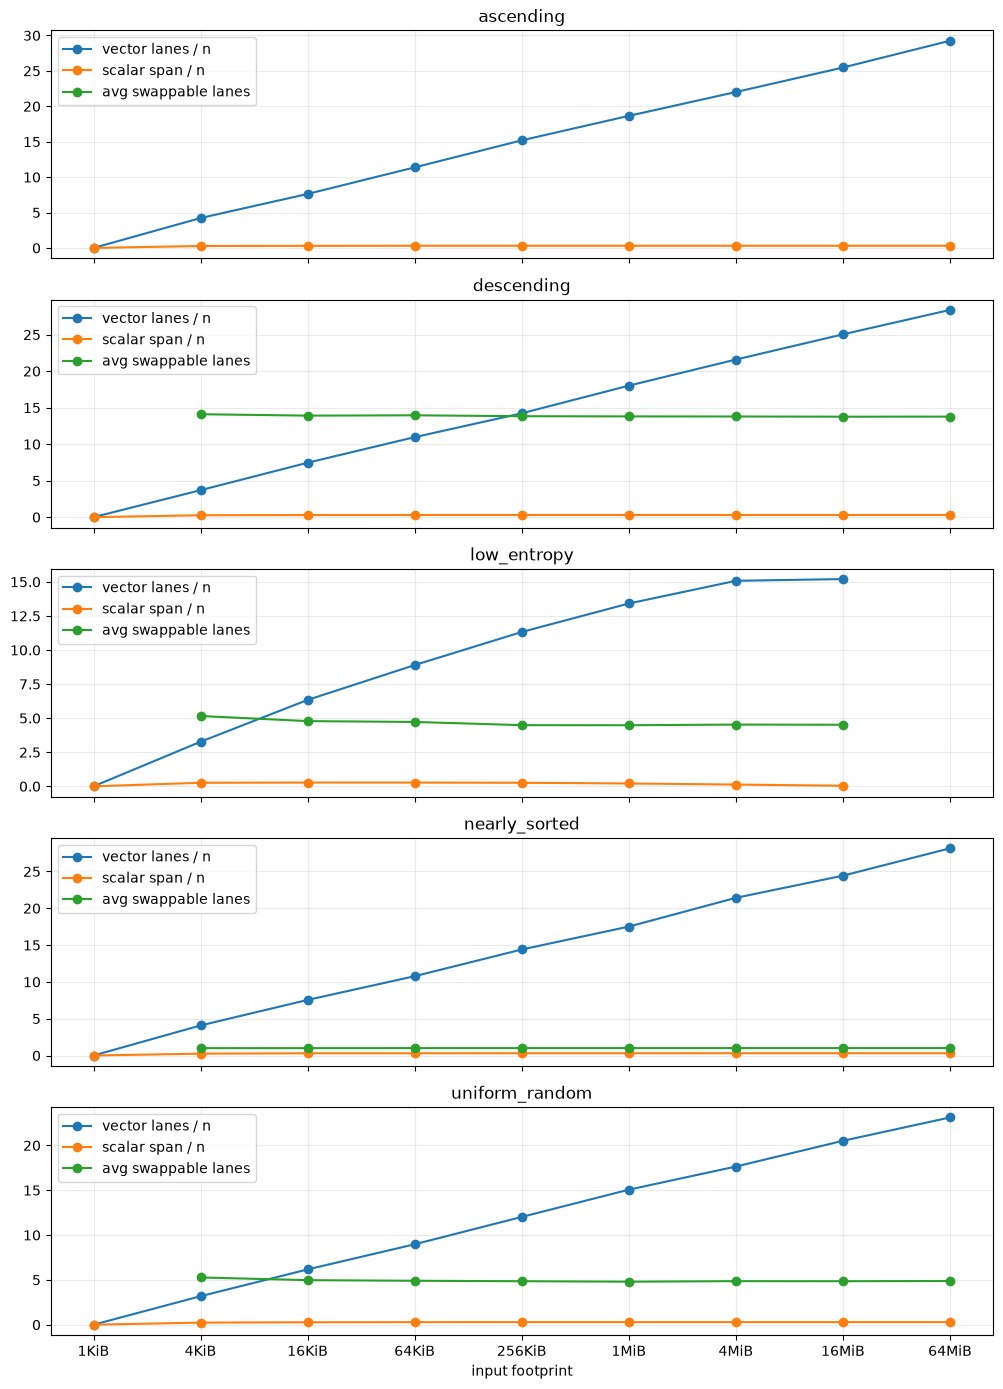

In [19]:
fig, axes = plt.subplots(len(distributions), 1, figsize=(10, 2.8 * len(distributions)), sharex=True)
if len(distributions) == 1:
    axes = [axes]

for axis, distribution in zip(axes, distributions):
    group = summary[summary['distribution'] == distribution].sort_values('bytes')
    axis.plot(group['bytes'], group['vector_lanes_per_element'], marker='o', label='vector lanes / n')
    axis.plot(group['bytes'], group['scalar_span_per_element'], marker='o', label='scalar span / n')
    axis.plot(group['bytes'], group['avg_swappable_lanes'], marker='o', label='avg swappable lanes')
    axis.set_xscale('log', base=2)
    axis.xaxis.set_major_formatter(mticker.FuncFormatter(format_bytes))
    axis.set_title(distribution)
    axis.grid(True, which='both', axis='both', alpha=0.25)
    axis.legend()

axes[-1].set_xlabel('input footprint')
fig.tight_layout()

## Bad-Lane Histograms

Pick a distribution and size to inspect the compact `lane_count:observations` histograms emitted by the trace.

selected_distribution='uniform_random' selected_size_label='64MiB' rows=30


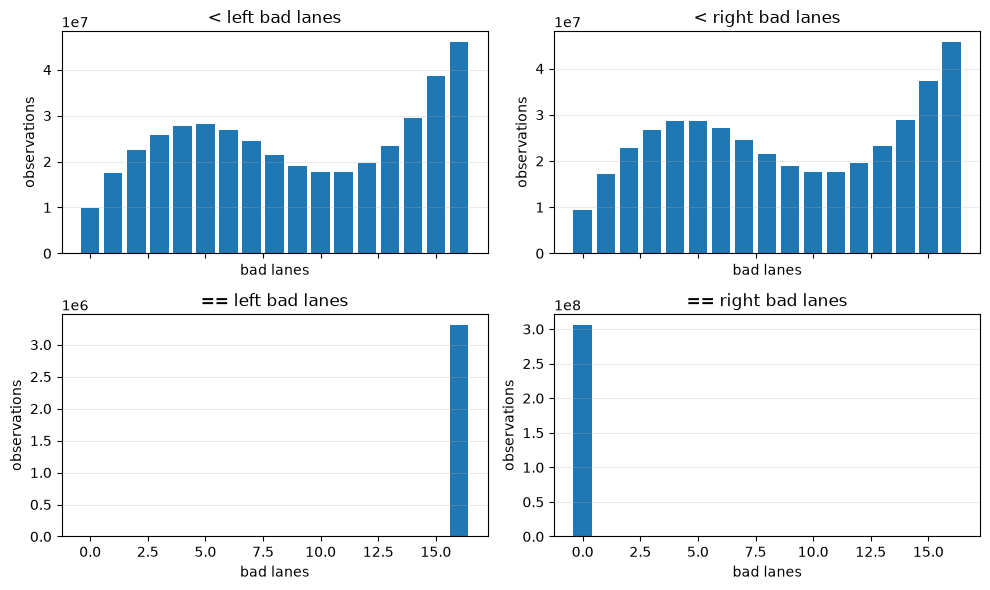

In [20]:
def parse_histogram_cell(value):
    if pd.isna(value) or value == 'empty':
        return Counter()
    result = Counter()
    for item in str(value).split(';'):
        lane_count, observations = item.split(':', 1)
        result[int(lane_count)] += int(observations)
    return result

def combine_histograms(values):
    total = Counter()
    for value in values:
        total.update(parse_histogram_cell(value))
    return pd.Series(dict(sorted(total.items())), dtype='int64')

selected_distribution = 'uniform_random' if 'uniform_random' in set(df['distribution']) else df['distribution'].iloc[0]
selected_size_label = df.loc[df['bytes'].idxmax(), 'size_label']
subset = df[(df['distribution'] == selected_distribution) & (df['size_label'] == selected_size_label)]
print(f'{selected_distribution=} {selected_size_label=} rows={len(subset)}')

histogram_plot_columns = [
    ('less_left_bad_lane_histogram', '< left bad lanes'),
    ('less_right_bad_lane_histogram', '< right bad lanes'),
    ('equal_left_bad_lane_histogram', '== left bad lanes'),
    ('equal_right_bad_lane_histogram', '== right bad lanes'),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for axis, (column, title) in zip(axes.ravel(), histogram_plot_columns):
    histogram = combine_histograms(subset[column])
    if histogram.empty:
        axis.text(0.5, 0.5, 'empty', ha='center', va='center', transform=axis.transAxes)
    else:
        axis.bar(histogram.index, histogram.values)
    axis.set_title(title)
    axis.set_xlabel('bad lanes')
    axis.set_ylabel('observations')
    axis.grid(True, axis='y', alpha=0.25)

fig.tight_layout()

## Worst Cases

This table is usually the fastest way to decide what to inspect next.

In [21]:
diagnostics = summary.copy()
diagnostics['leaf_pct'] = 100.0 * diagnostics['leaf_sort_ns'] / diagnostics['elapsed_ns'].where(diagnostics['elapsed_ns'] != 0)
diagnostics['less_pct'] = 100.0 * diagnostics['less_elapsed_ns'] / diagnostics['elapsed_ns'].where(diagnostics['elapsed_ns'] != 0)
diagnostics['equal_pct'] = 100.0 * diagnostics['equal_elapsed_ns'] / diagnostics['elapsed_ns'].where(diagnostics['elapsed_ns'] != 0)
diagnostics['partition_pct'] = 100.0 * diagnostics['partition_ns'] / diagnostics['elapsed_ns'].where(diagnostics['elapsed_ns'] != 0)

display_columns = [
    'distribution', 'size_label', 'trials', 'ns_per_element', 'max_depth',
    'leaf_pct', 'less_pct', 'equal_pct', 'partition_pct',
    'partition_input_per_element', 'scalar_span_per_element',
    'vector_lanes_per_element', 'avg_swappable_lanes',
]
diagnostics.sort_values('ns_per_element', ascending=False)[display_columns].head(20)

,distribution,size_label,trials,ns_per_element,max_depth,leaf_pct,less_pct,equal_pct,partition_pct,partition_input_per_element,scalar_span_per_element,vector_lanes_per_element,avg_swappable_lanes
43,uniform_random,64MiB,30,35.249218,33.0,58.645086,33.637862,5.673494,39.156582,29.488062,0.285777,23.122251,4.876722
42,uniform_random,16MiB,30,34.471268,29.0,62.020415,31.114933,4.720038,35.605991,26.174517,0.285703,20.517536,4.850159
41,uniform_random,4MiB,30,32.915749,25.0,65.759033,28.216811,3.532858,31.796089,22.557079,0.285717,17.646416,4.857435
39,uniform_random,256KiB,30,31.361961,16.0,73.019395,21.717042,2.822821,24.612649,15.471298,0.286491,12.025024,4.849700
20,low_entropy,16KiB,30,31.210083,8.0,80.386275,14.179831,2.673337,16.706887,8.311646,0.278198,6.341797,4.784068
36,uniform_random,4KiB,30,31.176270,4.0,85.749189,8.692384,1.976538,10.755063,4.351074,0.231934,3.179688,5.269136
40,uniform_random,1MiB,30,31.136374,21.0,68.958353,25.498867,3.187322,28.675745,19.168192,0.286209,15.064209,4.797282
19,low_entropy,4KiB,30,30.571289,4.0,85.347389,8.806900,2.384603,11.090880,4.433105,0.259277,3.273438,5.160194
37,uniform_random,16KiB,30,30.307495,8.0,81.033434,13.919421,2.300638,16.158837,8.140381,0.270142,6.167969,4.967161
22,low_entropy,256KiB,30,30.060860,15.5,69.307768,21.611812,5.947331,27.487547,14.812454,0.259628,11.326416,4.487808
